# Problem 1

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

### Part C: MC Predict

In [2]:
def fixed_policy(state):
    # Action space is Stick (0), Hit (1)
    player_sum, dealer_card, usable_ace = state
    if player_sum >= 20:
        return 0
    else:
        return 1

In [3]:
def mc_predict(episodes = 500000):
    env = gym.make('Blackjack-v1')

    V_sum = defaultdict(float)
    N = defaultdict(int)
    
    for i in range(episodes):
        if (i + 1) % 100000 == 0:
            print(f"Prediction Progress: Episode {i + 1} / {episodes}")
            
        state, _ = env.reset()
        episode = []
        done = False
        
        # Generate an episode
        while not done:
            action = fixed_policy(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode.append((state, reward))
            state = next_state
            
        # First-visit MC Update
        G = 0
        visited = set()
        for s, r in reversed(episode):
            G += r
            if s not in visited:
                visited.add(s)
                N[s] += 1
                V_sum[s] += G
                
    # Calculate final averages
    V = {s: V_sum[s] / N[s] for s in V_sum}
    env.close()
    return V

# Run prediction
print("Starting Monte Carlo Prediction...")
V = mc_predict(episodes = 500000)

Starting Monte Carlo Prediction...
Prediction Progress: Episode 100000 / 500000
Prediction Progress: Episode 200000 / 500000
Prediction Progress: Episode 300000 / 500000
Prediction Progress: Episode 400000 / 500000
Prediction Progress: Episode 500000 / 500000


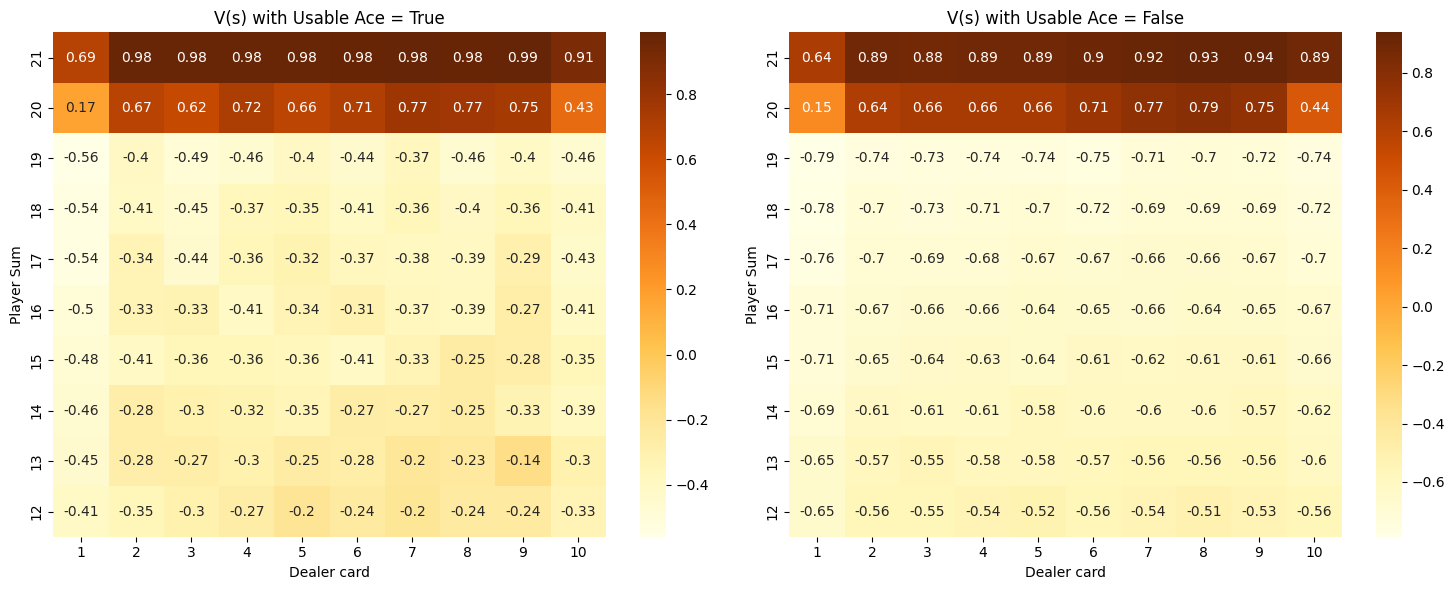

In [5]:
# Plot V(s) as a heatmap
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, usable_ace in enumerate([True, False]):
    grid = np.zeros((10, 10))
    for player_sum in range(12, 22):
        for dealer_card in range(1, 11):
            state = (player_sum, dealer_card, usable_ace)
            grid[player_sum - 12, dealer_card - 1] = V[state]
    ax = axes[i]
    sns.heatmap(grid, ax=ax, cmap="YlOrBr", xticklabels=range(1, 11), yticklabels=range(12, 22), annot=True).set(title="Part C: state value function")
    ax.set_title(f"V(s) with Usable Ace = {usable_ace}")
    ax.set_xlabel("Dealer card")
    ax.set_ylabel("Player Sum")
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Part D: MC Control

In [7]:
def get_egreedy_action(Q_state, epsilon, action_space_n):
    # Epsilon-soft exploration
    if np.random.rand() < epsilon:
        return np.random.choice(action_space_n)
    else:
        # Break ties randomly to avoid getting stuck early on
        best_actions = np.argwhere(Q_state == np.amax(Q_state)).flatten()
        return np.random.choice(best_actions)

def mc_control(episodes = 500000, epsilon = 0.1):
    env = gym.make('Blackjack-v1')
    action_space_n = env.action_space.n
    
    # Init Q(s,a) and N(s,a)
    Q = defaultdict(lambda: np.zeros(action_space_n))
    N = defaultdict(lambda: np.zeros(action_space_n))
    
    for i in range(episodes):
        if (i + 1) % 100000 == 0:
            print(f"Control Progress: Episode {i + 1}/{episodes}")
            
        state, _ = env.reset()
        episode = []
        done = False
        
        # Generate an episode
        while not done:
            action = get_egreedy_action(Q[state], epsilon, action_space_n)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode.append((state, action, reward))
            state = next_state
            
        # First-visit MC Update for Action Values
        G = 0
        visited_sa = set()
        for s, a, r in reversed(episode):
            G += r
            if (s, a) not in visited_sa:
                visited_sa.add((s, a))
                N[s][a] += 1
                # Incremental average update
                Q[s][a] += (G - Q[s][a]) / N[s][a]
                
    # Extract the greedy policy from the learned Q-values
    learned_policy = {s: np.argmax(q) for s, q in Q.items()}
    env.close()
    return learned_policy

# Run control
print("Starting Monte Carlo Control...")
learned_policy = mc_control(episodes = 500000, epsilon = 0.1)

Starting Monte Carlo Control...
Control Progress: Episode 100000/500000
Control Progress: Episode 200000/500000
Control Progress: Episode 300000/500000
Control Progress: Episode 400000/500000
Control Progress: Episode 500000/500000


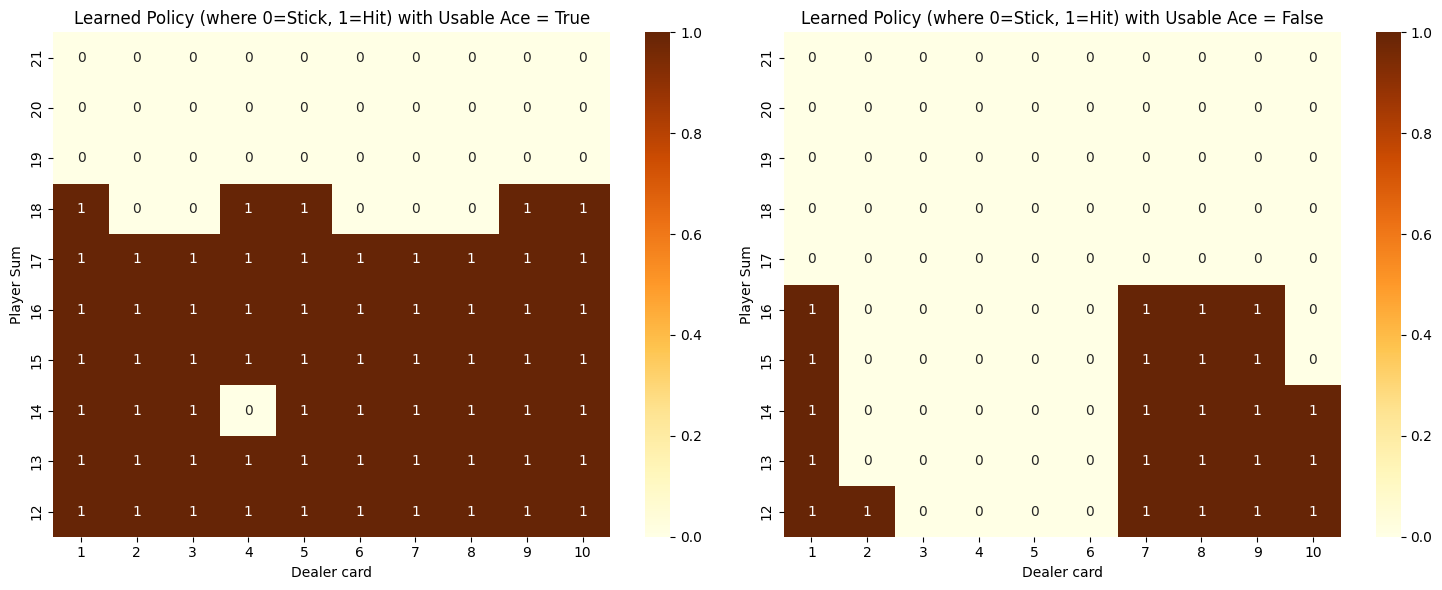

In [8]:
# Plot learned policy as a heatmap
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, usable_ace in enumerate([True, False]):
    grid = np.zeros((10, 10))
    for player_sum in range(12, 22):
        for dealer_card in range(1, 11):
            state = (player_sum, dealer_card, usable_ace)
            grid[player_sum - 12, dealer_card - 1] = learned_policy[state]
    
    ax = axes[i]
    sns.heatmap(grid, ax=ax, cmap="YlOrBr", xticklabels=range(1, 11), yticklabels=range(12, 22), annot=True).set(title="Part D: learned greedy policy")
    ax.set_title(f"Learned Policy (where 0=Stick, 1=Hit) with Usable Ace = {usable_ace}")
    ax.set_xlabel("Dealer card")
    ax.set_ylabel("Player Sum")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()